# Mobile Price Classification

Bob has started his own mobile company. He wants to give tough fight to big companies like Apple,Samsung etc.

He does not know how to estimate price of mobiles his company creates. In this competitive mobile phone market you cannot simply assume things. To solve this problem he collects sales data of mobile phones of various companies.

Source url:
https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification/data

# Part 1. Problem Definition
In this problem you do not have to predict actual price but a price range indicating how high the price is

# Part 2. Data

The dataset i have been using is from train.csv that i downloaded from kaggle form the mentioned source url

# Part 3. Evaluation
If the model can reach 60% or more higher Kappa Statistic then we will be pursue the model

source: https://www.statology.org/cohens-kappa-statistic/

# Part 4. Feature
The feature of dataset is

1. **battery_power**
Total energy a battery can store in one time measured in mAh
2. **blue**
Has bluetooth or not
3. **clock_speed**
speed at which microprocessor executes instructions
4. **dual_sim**
Has dual sim support or not
5. **fc**
Front Camera mega pixels
6. **four_g**
Has 4G or not
7. **int_memory**
Internal Memory in Gigabytes
8. **m_dep**
Mobile Depth in cm
9. **mobile_wt**
Weight of mobile phone
10. **n_cores**
Number of cores of processor
11. **pc**
Primary Camera mega pixels
12. **px_height**
Pixel Resolution Height
13. **px_width**
Pixel Resolution Width
14. **ram**
Random Access Memory in Mega Bytes
15. **sc_h**
Screen Height of mobile in cm
16. **sc_w**
Screen Width of mobile in cm
17. **talk_time**
longest time that a single battery charge will last when you are
18. **three_g**
Has 3G or not
19. **touch_screen**
Has touch screen or not
20. **wifi**
Has wifi or not
21. **price_range**
This is the target variable with value of 0(low cost), 1(medium cost), 2(high cost) and 3(very high cost).

# Preparing the tools
We're going to use pandas, Matplotlib and NumPy for data analysis and manipulation.

In [1]:
# Import all the tools we need

# Regular EDA (exploratory data analysis) and plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# we want our plots to appear inside the notebook 
%matplotlib inline

# Models from Scikit-Learn
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

# Model evaluation
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# Load data

In [3]:
df = pd.read_csv("dataset/train.csv")
print(df.shape) # (rows, columns)

(2000, 21)


# Data Exploration (exploratory data analysis or EDA)
1. What question(s) are you trying to solve (or prove wrong)?
2. What kind of data do you have and how do you treat different types?
3. What's missing from the data and how do you deal with it?
4. Where are the outliers and why should you care about them?
5. How can you add, change or remove features to get more out of your data?

In [4]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [5]:
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [6]:
df.tail()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0
1999,510,1,2.0,1,5,1,45,0.9,168,6,...,483,754,3919,19,4,2,1,1,1,3


In [7]:
# Check the target variable portion
df["price_range"].value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

<Axes: xlabel='price_range'>

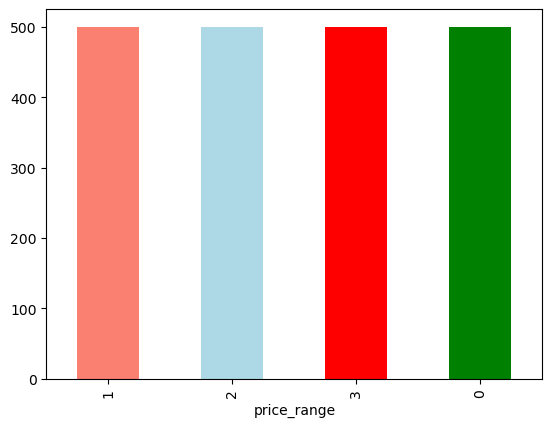

In [8]:
df["price_range"].value_counts().plot(kind="bar", color=["salmon", "lightblue", "red", "green"])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [10]:
# check the missing values
df.isna().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [11]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


## Price Range Frequency according to n_cores

In [12]:
df['n_cores'].value_counts()

n_cores
4    274
7    259
8    256
2    247
3    246
5    246
1    242
6    230
Name: count, dtype: int64

In [13]:
# compare price range column with n_cores column
pd.crosstab(df['price_range'], df['n_cores'])

n_cores,1,2,3,4,5,6,7,8
price_range,,,,,,,,
0,49,69,62,67,59,61,66,67
1,76,59,69,76,51,54,55,60
2,52,57,56,73,66,57,69,70
3,65,62,59,58,70,58,69,59


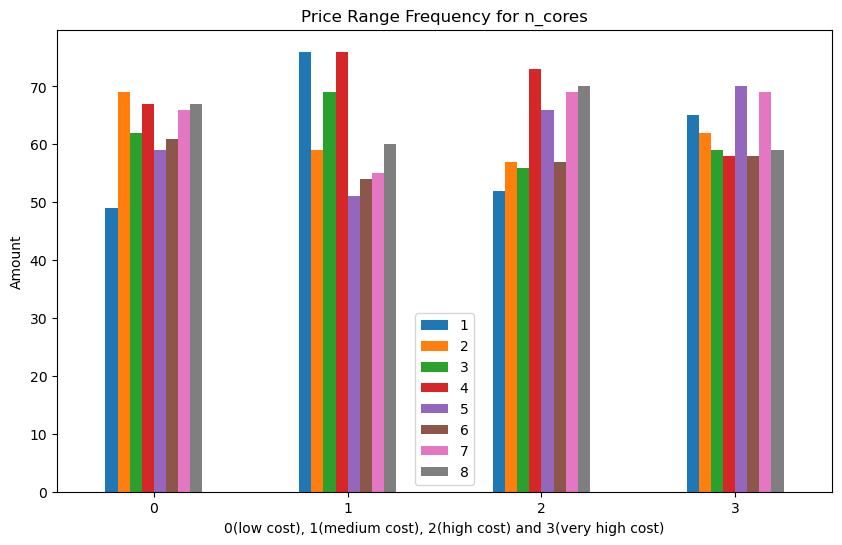

In [14]:
# Create a plot of crosstab
pd.crosstab(df['price_range'], df['n_cores']).plot(kind="bar",
                                                   figsize=(10,6))

plt.title("Price Range Frequency for n_cores")
plt.xlabel("0(low cost), 1(medium cost), 2(high cost) and 3(very high cost)")
plt.ylabel("Amount")
plt.legend(["1","2","3","4","5","6","7","8"])
plt.xticks(rotation=0);

In [24]:
# make copy of df for check the argument 1(medium cost)
df2 = df.copy()
df2.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [27]:
# filtered data for price_range 1
df2_filtered = df2.query('price_range == 1')
df2_filtered.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
5,1859,0,0.5,1,3,0,22,0.7,164,1,...,1004,1654,1067,17,1,10,1,0,0,1
12,1815,0,2.8,0,2,0,33,0.6,159,4,...,607,748,1482,18,0,2,1,0,0,1
18,1131,1,0.5,1,11,0,49,0.6,101,5,...,658,878,1835,19,13,16,1,1,0,1


In [29]:
# I want to check the argument of n_cores hightest distribution
df2_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 1989
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  500 non-null    int64  
 1   blue           500 non-null    int64  
 2   clock_speed    500 non-null    float64
 3   dual_sim       500 non-null    int64  
 4   fc             500 non-null    int64  
 5   four_g         500 non-null    int64  
 6   int_memory     500 non-null    int64  
 7   m_dep          500 non-null    float64
 8   mobile_wt      500 non-null    int64  
 9   n_cores        500 non-null    int64  
 10  pc             500 non-null    int64  
 11  px_height      500 non-null    int64  
 12  px_width       500 non-null    int64  
 13  ram            500 non-null    int64  
 14  sc_h           500 non-null    int64  
 15  sc_w           500 non-null    int64  
 16  talk_time      500 non-null    int64  
 17  three_g        500 non-null    int64  
 18  touch_screen  

In [46]:
df2_filtered["clock_speed"].describe()

count    500.000000
mean       1.488600
std        0.814479
min        0.500000
25%        0.600000
50%        1.500000
75%        2.200000
max        3.000000
Name: clock_speed, dtype: float64

## Bluetooth acording to price_range medium

In [33]:
df2_filtered.blue.value_counts()

blue
0    255
1    245
Name: count, dtype: int64

In [37]:
# compare price_range medium with bluetooth column
pd.crosstab(df2_filtered["price_range"], df2_filtered["blue"])

blue,0,1
price_range,,
1,255,245


## check the distribution bluetooth for lowest n_cores

In [40]:
# filtered data for price_range 0
df2_filtered_pr0 = df2.query('price_range == 0')
df2_filtered_pr0.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
7,1954,0,0.5,1,0,0,24,0.8,187,4,...,512,1149,700,16,3,5,1,1,1,0
8,1445,1,0.5,0,0,0,53,0.7,174,7,...,386,836,1099,17,1,20,1,0,0,0
9,509,1,0.6,1,2,1,9,0.1,93,5,...,1137,1224,513,19,10,12,1,0,0,0
14,1866,0,0.5,0,13,1,52,0.7,185,1,...,356,563,373,14,9,3,1,0,1,0
15,775,0,1.0,0,3,0,46,0.7,159,2,...,862,1864,568,17,15,11,1,1,1,0


In [41]:
df2_filtered_pr0.blue.value_counts()

blue
0    257
1    243
Name: count, dtype: int64

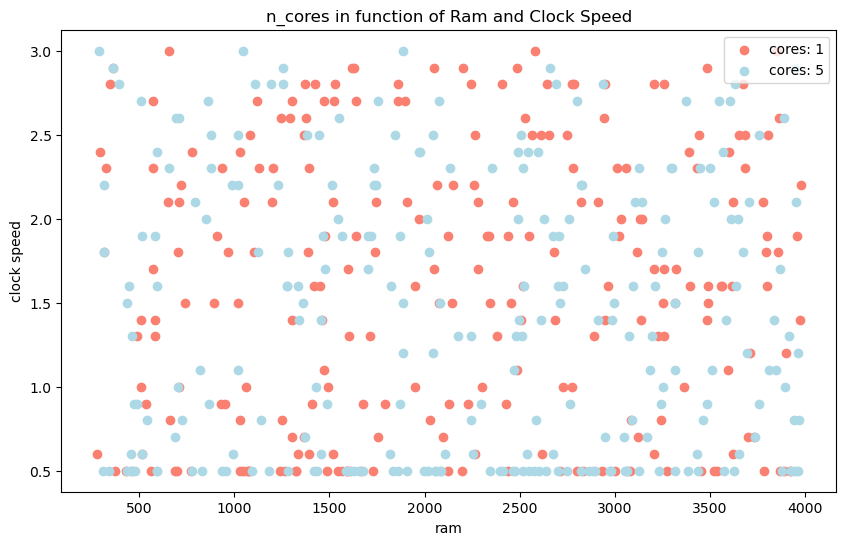

In [52]:
# Create another figure
plt.figure(figsize=(10, 6))

# Scatter with postivie examples
plt.scatter(df["ram"][df["n_cores"] == 1],
            df["clock_speed"][df["n_cores"] == 1],
            c="salmon")

# Scatter with negative examples
plt.scatter(df["ram"][df["n_cores"] == 5],
            df["clock_speed"][df["n_cores"] == 5],
            c="lightblue")

# Add some helpful info
plt.title("n_cores in function of Ram and Clock Speed")
plt.xlabel("ram")
plt.ylabel("clock speed")
plt.legend(["cores: 1", "cores: 5"]);

## There is no correlation